# Sparse Autoencoder - primjeri

In [87]:
from SparseAutoencoder import SparseAutoencoder
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

Za početak radimo na skupu 8x8 slika rukom pisanih znamenki. Svaku znamenku predstavimo kao vektor duljine 15 u $\textit{bottleneck}$ sloju.

In [136]:
autoencoderSparse = SparseAutoencoder(velicine_slojeva = [64, 15, 64], bottleneck_sloj=1)

In [137]:
znamenke = load_digits()
znamenke = znamenke.data / 16.0

In [143]:
X_train, X_test = train_test_split(znamenke, test_size=0.2)

In [144]:
X_train

array([[0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ],
       [0.    , 0.25  , 0.9375, ..., 0.5   , 0.    , 0.    ],
       [0.    , 0.    , 0.3125, ..., 0.1875, 0.    , 0.    ],
       ...,
       [0.    , 0.    , 0.4375, ..., 0.125 , 0.    , 0.    ],
       [0.    , 0.    , 0.5   , ..., 0.3125, 0.    , 0.    ],
       [0.    , 0.    , 0.    , ..., 0.    , 0.    , 0.    ]],
      shape=(1437, 64))

In [145]:
autoencoderSparse.train(X_train, X_train, n_epochs = 30, eta = 0.02)

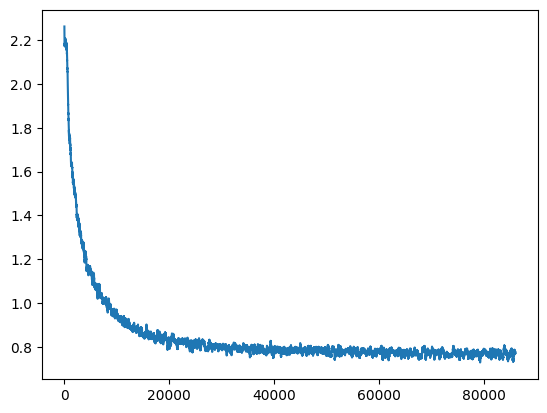

In [146]:
prozor = 200
glatki_graf = np.convolve(autoencoderSparse.greske, np.ones(prozor)/prozor, mode='valid')
plt.plot(glatki_graf)

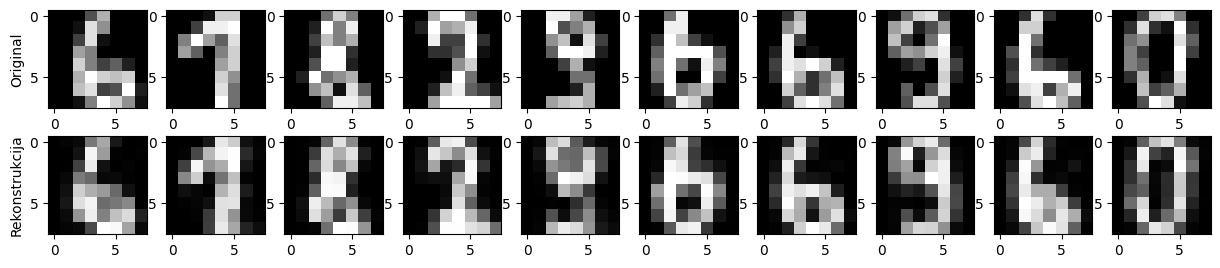

In [147]:
fig, axes = plt.subplots(2, 10, figsize=(15, 3))
for i in range(10):
    output = autoencoderSparse.forwardPass(X_test[i])
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap='gray')
    axes[1, i].imshow(output.reshape(8, 8), cmap='gray')
axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Rekonstrukcija")
plt.show()

## Detekcija anomalija u NSL-KDD skupu podataka

NSL-KDD poznat je skup podataka za testiranje metoda za detekciju anomalija u mrežnoj sigurnosti. Skup sadrži zapise TCP poruka unutar simulirane vojne mreže koju su uspostavili ARPANET i MIT 1998. Ukupno ima više od 125 000 zapisa, od kojih je otprilike pola maliciozno/predstavljaju mrežne napade. Cilj je detektirati te maliciozne napade.

U tu svrhu možemo koristiti sparse autoencodere - dodatnim uvjetom na rijetkost reprezentacije osiguravamo da je ona osjetljivija na šum; ako se ulazni podatak ne poklapa s neuronima $\textit{bottleneck}$ sloja koji nisu blizu 0, tj. točno onima koji su "naučili" latentna svojstva, rekonstrukcija će mu biti loša. Ovdje je riječ o suprotnom zadatku od uklanjanja šuma u podacima, jer mi želimo što više udaljiti iole sumjive podatke od "čistih".

In [264]:
df = pd.read_csv('../data/KDDTrain+.csv', header=None)

# Predzadnji stupac je vrsta napada, zadnji stupac je težina klasifikacije - to su metapodaci, mičem ih
labels = df.iloc[:, -2]
df = df.drop(columns=[df.columns[-1], df.columns[-2]])

# Stupce koje imaju kategoričke vrijednosti kodiram...
df = pd.get_dummies(df)

# Normalizacija
X_KDD = df.to_numpy(dtype=np.float64)
X_KDD = X_KDD / (X_KDD.max(axis=0) + 1e-8)

# Treniram na normalnom mrežnom prometu
X_normal = X_KDD[labels == 'normal']
X_train_normal, X_test_normal = train_test_split(X_normal, test_size=0.2)

# Testiram na svemu
X_test_all = X
labels_test = labels.to_numpy()

In [265]:
labels_test

array(['normal', 'normal', 'neptune', ..., 'normal', 'neptune', 'normal'],
      shape=(125973,), dtype=object)

In [149]:
X_normal.shape

(67343, 122)

In [226]:
KDDencoder = SparseAutoencoder([122, 32, 122], bottleneck_sloj=1)

In [227]:
KDDencoder.train(X_train_normal, X_train_normal, n_epochs=3, eta=0.01)

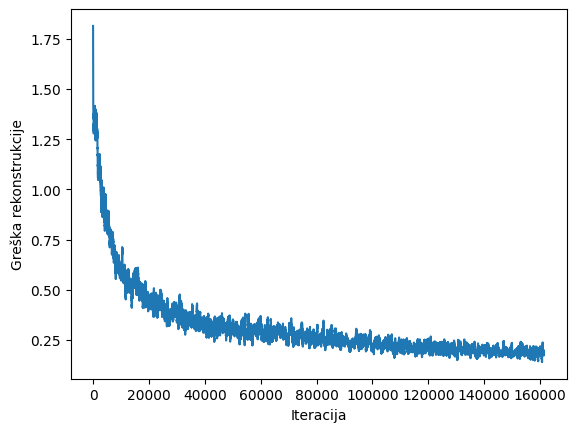

In [239]:
prozor = 200
glatki_graf = np.convolve(KDDencoder.greske, np.ones(prozor)/prozor, mode='valid')
plt.xlabel('Iteracija')
plt.ylabel('Greška rekonstrukcije')
plt.plot(glatki_graf)

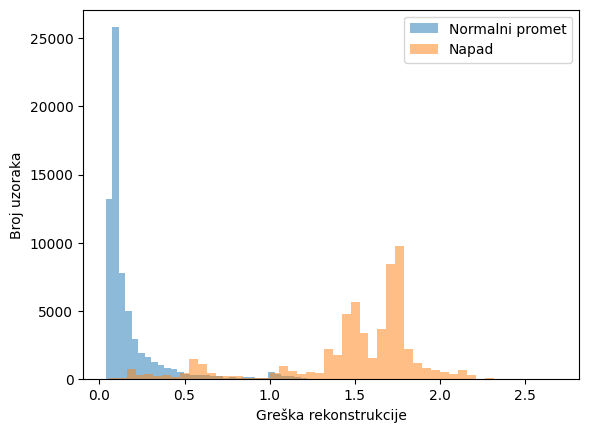

In [228]:
greske = []
for i in range(len(X_test_all)):
    output = KDDencoder.forwardPass(X_test_all[i])
    greske.append(np.linalg.norm(output - X_test_all[i]))

greske = np.array(greske)

# Prikazujem distribuciju na grafu
normal_greske = greske[labels_test == 'normal']
napadi_greske = greske[labels_test != 'normal']

plt.hist(normal_greske, bins=50, alpha=0.5, label='Normalni promet')
plt.hist(napadi_greske, bins=50, alpha=0.5, label='Napad')
plt.xlabel('Greška rekonstrukcije')
plt.ylabel('Broj uzoraka')
plt.legend()
plt.show()

Vidimo da je model dobro separirao zapise napada od zapisa koji odgovaraju redovnom mrežnom prometu. U stvarnom sustavu postavili bismo prag na grešku rekonstrukcije koju toleriramo. Sve iznad tog praga klasificirali bismo kao anomaliju/napad.

In [256]:
threshold = 0.5
y_pred = (greske > threshold).astype(int)
y_true = (labels_test != 'normal').astype(int)

# propušteni napadi (ispod threshold)
propusteni_napadi = np.where((y_true == 1) & (y_pred == 0))[0]
print(f"Broj propuštenih napada: {len(propusteni_napadi)}")
print(pd.Series(labels_test[propusteni_napadi]).value_counts())

Broj propuštenih napada: 2414
back               784
warezclient        762
ipsweep            303
nmap               289
satan              237
warezmaster         19
buffer_overflow      6
multihop             5
rootkit              4
ftp_write            4
loadmodule           1
Name: count, dtype: int64


In [257]:
print(pd.Series(labels_test).value_counts())

normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [263]:
rezultati = []
for tip_napada in np.unique(labels_test[labels_test != 'normal']):
    ukupno = np.sum(labels_test == tip_napada)
    propusteni = np.sum((labels_test == tip_napada) & (y_pred == 0))
    avg_error = np.mean(errors[labels_test == tip_napada])
    rezultati.append((tip_napada, propusteni, ukupno, propusteni/ukupno*100, avg_error))

rezultati.sort(key=lambda x: x[3], reverse=True)
for tip, propusteni, ukupno, postotak, avg_err in rezultati:
    propusteno_str = f"{propusteni}/{ukupno}"
    print(f"{tip:<20} {propusteno_str:<12} {'propušteno':>12} ({postotak:>5.1f}%) | avg greška: {avg_err:.3f}")
ukupno_propusteno = np.sum((labels_test != 'normal') & (y_pred == 0))
ukupno_napada = np.sum(labels_test != 'normal')
print(f"{'ukupno propušteno':<20} {ukupno_propusteno:<12} {'propušteno':>12} ({ukupno_propusteno/ukupno_napada*100:>5.1f}%)")

warezmaster          19/20          propušteno ( 95.0%) | avg greška: 0.275
warezclient          762/890        propušteno ( 85.6%) | avg greška: 0.329
back                 784/956        propušteno ( 82.0%) | avg greška: 0.320
multihop             5/7            propušteno ( 71.4%) | avg greška: 0.595
ftp_write            4/8            propušteno ( 50.0%) | avg greška: 0.591
rootkit              4/10           propušteno ( 40.0%) | avg greška: 0.634
buffer_overflow      6/30           propušteno ( 20.0%) | avg greška: 0.901
nmap                 289/1493       propušteno ( 19.4%) | avg greška: 0.759
loadmodule           1/9            propušteno ( 11.1%) | avg greška: 0.889
ipsweep              303/3599       propušteno (  8.4%) | avg greška: 0.675
satan                237/3633       propušteno (  6.5%) | avg greška: 1.599
guess_passwd         0/53           propušteno (  0.0%) | avg greška: 1.452
imap                 0/11           propušteno (  0.0%) | avg greška: 1.592
land        

Vidimo da je ukupno propušteno 2414 napada od njih cca. 60 000. Napade čiji su zapisi znatno različiti od normalnih TCP poruka lako klasificiramo, poput neptune (točno smo uhvatili svih 41 000+ zapisa!) ili portsweep napada, koji šalju TCP zahtjeve patoloških/nestandardnih oblika (zahtjevi vrlo kratkog trajanja bez ikakvih prenesenih podataka). Sofisticiraniji napadi koji se vješto pretvaraju da su običan promet, ili je njihov maliciozni sadržaj van samog zapisa o TCP poruci (npr. maliciozan je sadržaj koji se preko uspostavljene veze pošalje, kao kod warezmaster napada, ili je zahtjev standardan na mrežnom sloju, ali na specifičnom softveru aplikacijskog sloja uzrokuje rušenje sustava, kao back napad na Apache web serveru) prolaze prag i naš ih sustav ne može dobro klasificirati.